<a href="https://colab.research.google.com/github/kishansharathgowda23-oss/PCOS-PCOD-ML-mini-project/blob/main/Mlcomb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving combined_500.csv to combined_500.csv

===== Random Forest =====
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


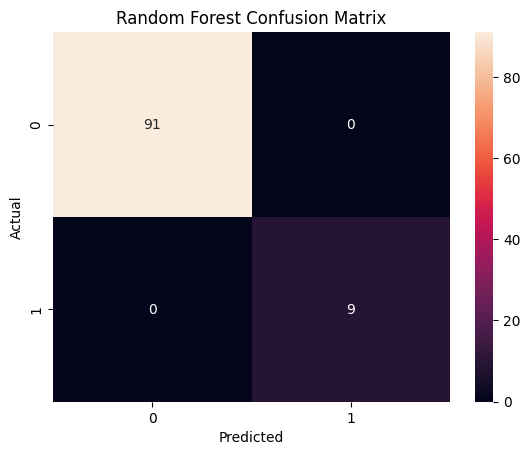


===== Logistic =====
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


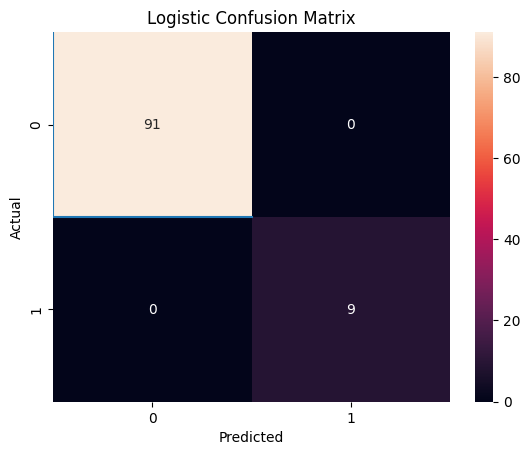


===== KNN =====
Accuracy : 0.91
Precision: 0.5
Recall   : 0.4444444444444444
F1 Score : 0.47058823529411764


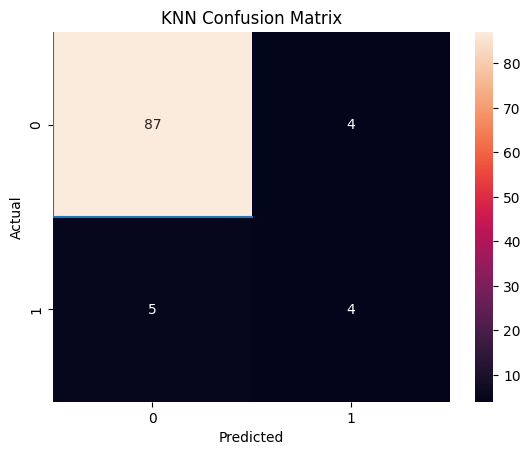

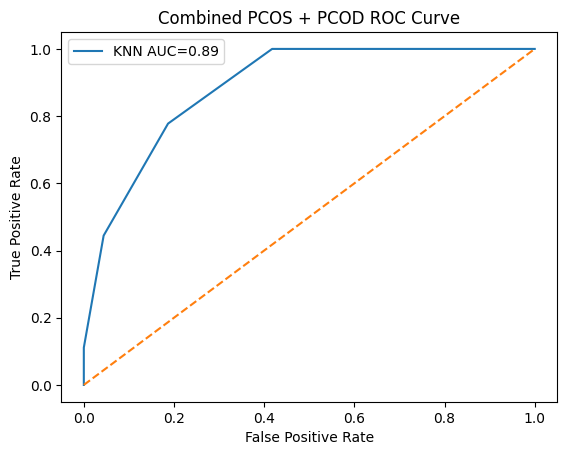


===== FINAL MODEL COMPARISON TABLE =====
           Model  Accuracy  Precision    Recall  F1 Score
0  Random Forest      1.00        1.0  1.000000  1.000000
1       Logistic      1.00        1.0  1.000000  1.000000
2            KNN      0.91        0.5  0.444444  0.470588


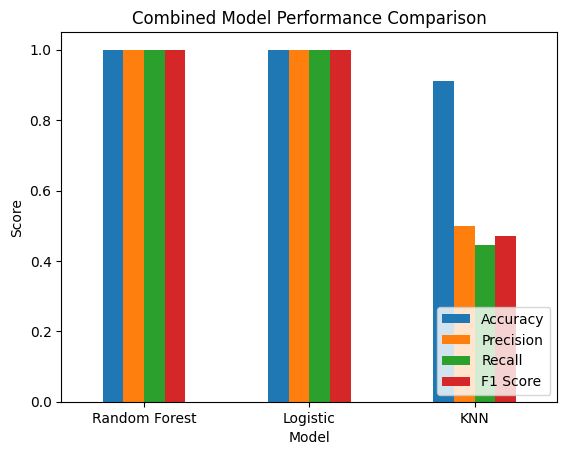

In [ ]:
# ===== COMBINED MODEL USING CSV UPLOAD =====

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Upload CSV
from google.colab import files
uploaded = files.upload()   # Upload combined_500.csv

df = pd.read_csv(list(uploaded.keys())[0])

# ===== IMPORT MODELS =====
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# ===== METRICS =====
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# ===== DATA SPLIT =====
X = df.drop('PCOS_PCOD', axis=1)
y = df['PCOS_PCOD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# ===== MODELS =====
models = {
    "Random Forest": RandomForestClassifier(),
    "Logistic": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier()
}

# ===== STORE RESULTS =====
results = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": []
}

# ===== TRAIN + EVALUATE =====
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n===== {name} =====")

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)

    print("Accuracy :", acc)
    print("Precision:", pre)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    # Save results
    results["Model"].append(name)
    results["Accuracy"].append(acc)
    results["Precision"].append(pre)
    results["Recall"].append(rec)
    results["F1 Score"].append(f1)

    # ===== CONFUSION MATRIX =====
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
    plt.title(name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ===== ROC CURVE =====
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} AUC={roc_auc:.2f}")

# ===== FINAL ROC =====
plt.plot([0,1], [0,1], '--')
plt.title("Combined PCOS + PCOD ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# ===== BAR GRAPH COMPARISON (NEW ADDITION) =====
results_df = pd.DataFrame(results)

print("\n===== FINAL MODEL COMPARISON TABLE =====")
print(results_df)

# Bar Chart
results_df.set_index("Model").plot(kind="bar")

plt.title("Combined Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()